<a href="https://colab.research.google.com/github/jcdevaney/musicComputing2026/blob/main/week8/additiveSynthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display

In [2]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):

    # generate list of harmonics
    harmonics = np.arange(1,numHarmonics+1,seqHarm)

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot

    return signal

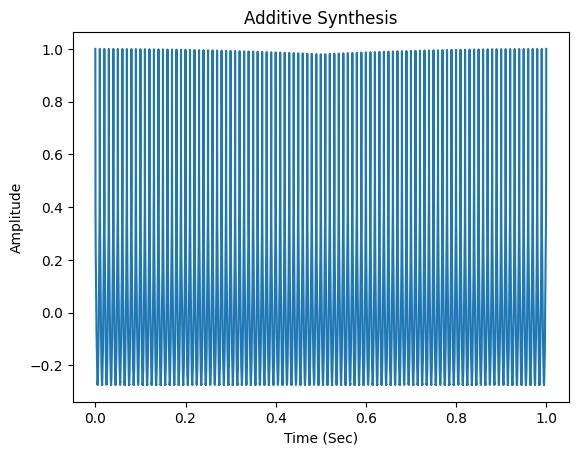

In [3]:
samplingRate = 44100
frequency = 100
numHarmonics = 100
waveType = 'sawtooth'

# if, elif (else if) and else can be used to evaluate the contents of a variable
if waveType == 'sawtooth':
    seqHarm = 1
    ampExponent = 1
elif waveType == 'square':
    seqHarm = 2
    ampExponent = 1
elif waveType == 'triangle':
    seqHarm = 2
    ampExponent = 2
else:
    numHarmonics = 1
    seqHarm = 1
    ampExponent = 1

signal = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)

# play signal
IPython.display.Audio(data=signal, rate=samplingRate)

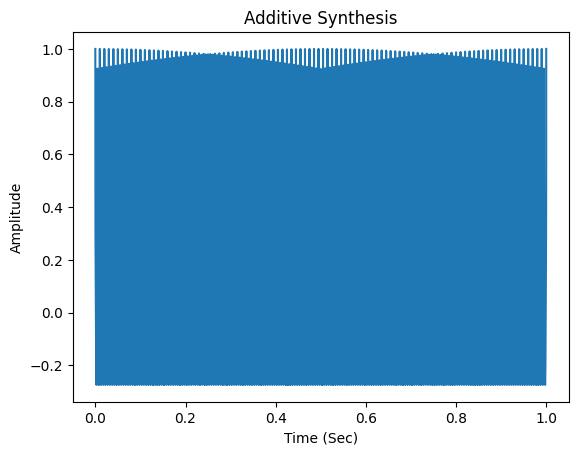

In [4]:
samplingRate = 44100
frequency = 200
numHarmonics = 100
waveType = 'sawtooth'

# if, elif (else if) and else can be used to evaluate the contents of a variable
if waveType == 'sawtooth':
    lowestHarm = 1
    seqHarm = 1
    ampExponent = 1
elif waveType == 'square':
    lowestHarm = 1
    seqHarm = 2
    ampExponent = 1
elif waveType == 'triangle':
    lowestHarm = 1
    seqHarm = 2
    ampExponent = 2
else:
    lowestHarm = 1
    numHarmonics = 1
    seqHarm = 1
    ampExponent = 1

signal2 = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)
IPython.display.Audio(data=signal2, rate=samplingRate)

## You can combine signals by using the plus sign (+)

In [5]:
IPython.display.Audio(data=signal+signal2, rate=samplingRate)

## The signal library in scipy has built in wave generator functions

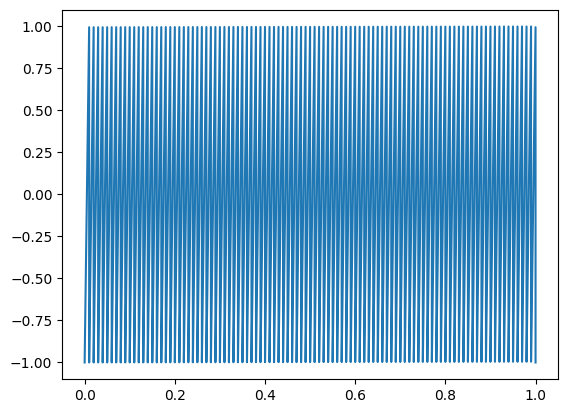

In [6]:
from scipy import signal
t = np.linspace(0, 1, 44100)
plt.plot(t, signal.sawtooth(2 * np.pi * 100 * t))
IPython.display.Audio(data=signal.sawtooth(2 * np.pi * 100 * t), rate=samplingRate)

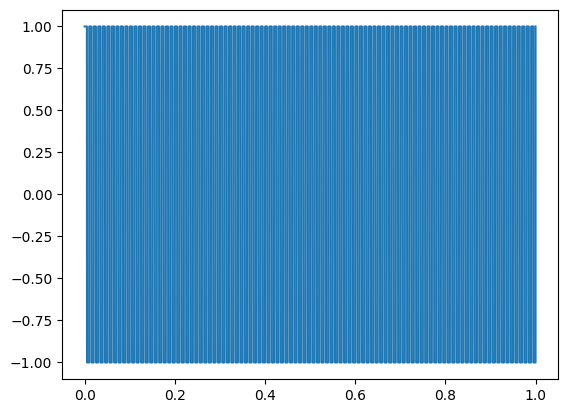

In [7]:
plt.plot(t, signal.square(2 * np.pi * 100 * t))
IPython.display.Audio(data=signal.square(2 * np.pi * 100 * t), rate=samplingRate)

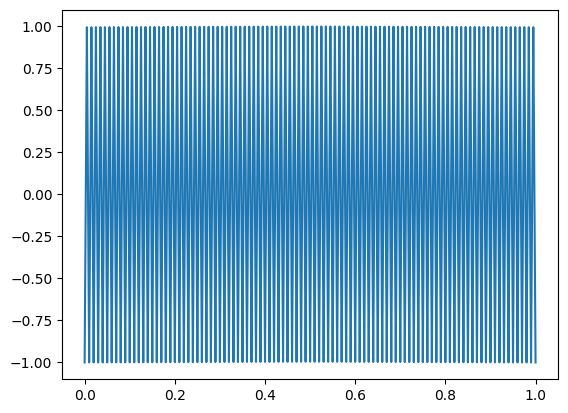

In [8]:
plt.plot(t, signal.sawtooth(2 * np.pi * 100 * t, width = 0.5))
IPython.display.Audio(data=signal.sawtooth(2 * np.pi * 100 * t, width = 0.5), rate=samplingRate)